saved g2d2_fixed_all3.pdf/.png | N per pipeline = 72,001 | QCW post-mask total = 239,526 | Loki total = 99,980,000


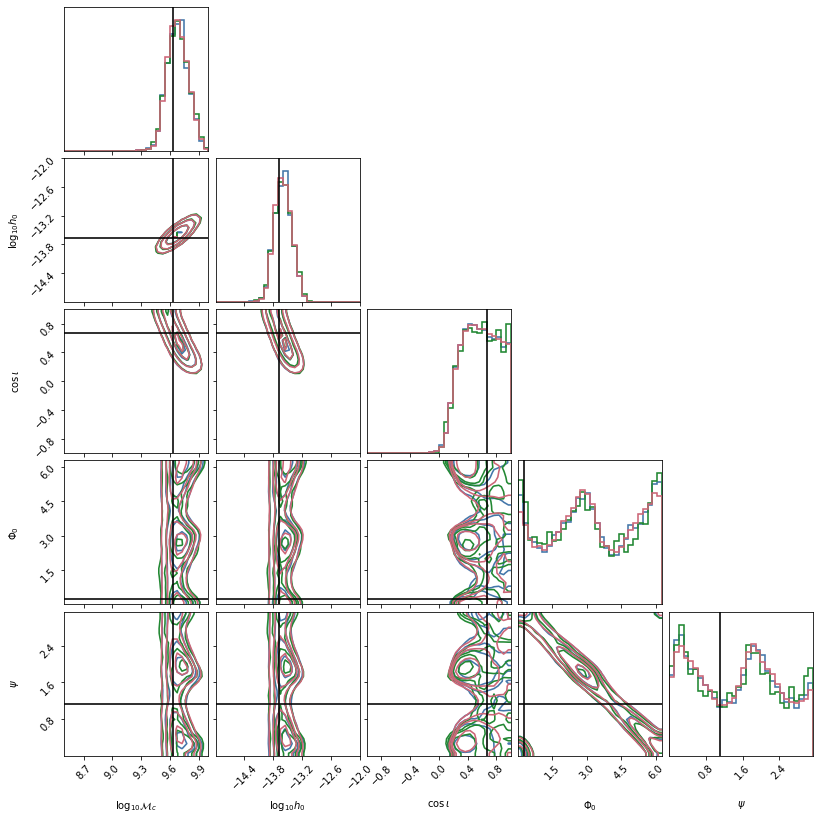

In [7]:
# =====================================================================
# Publication three-pipeline corner figure (G2D2 detection).
# No legend, no title: color mapping and test description go in the
# caption. Contour only, truths in black, Paul Tol colorblind-safe set.
# Loading conventions mirror compare_G2D2_*_three_pipelines_corrected_
# tref_latest.ipynb exactly:
#   QuickCW    -> f["samples_masked"], h0 = "0_log10_h" (sampled)
#   LokiCW     -> f["samples_cold"][0], h0 derived from Mc, fGW, dL
#   Enterprise -> f["chain"][ENT_BURN:], h0 derived, dL fixed 75.4 Mpc
# QCW and Loki are randomly subsampled to Enterprise's post-burn count.
# Truths are the exact MDC2 injection JSON values
# (github.com/ipta/mdc2, group2/group2_gw_parameters.json).
# NOTE the cos iota fix: the JSON key is "inclination" in RADIANS
# (0.8412486994612669), so the truth line is cos(0.84125) = 0.6660.
# The compare_* notebooks plot 0.84125 directly, which is wrong;
# g2d2_3_pipeline_corner used np.cos(0.841) (rounded input).
# Output filenames match the Overleaf includegraphics names.
# =====================================================================
import numpy as np
import h5py
import corner

np.random.seed(42)
FIXED = True   # set True for the fixed-fGW figure

if FIXED:
    QCW_FILE  = "/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_narrow_detect_tref_09_Jun_2026_dLmasked_75.400Mpc.h5"
    LOKI_FILE = "/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_fixed_detect_loki_100M_lastTOA_02_Jun_2026.h5"
    ENT_FILE  = "/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_core_fixed_new.h5"
    OUTNAME   = "g2d2_fixed_all3"
else:
    QCW_FILE  = "/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_broad_detect_tref_09_Jun_2026_dLmasked_75.400Mpc.h5"
    LOKI_FILE = "/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_broad_detect_loki_100M_lastTOA_02_Jun_2026.h5"
    ENT_FILE  = "/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_varyfgw_core_new.h5"
    OUTNAME   = "g2d2_broad_all3"
ENT_BURN = 3000

# constants and h0 derivation (identical to the compare notebooks;
# reproduces the injected log_10_h = -13.668773 exactly)
megaparsec = 3.086e22
speed_of_light = 299792458.0
T_sun = 1.327124400e20 / speed_of_light**3
D_MPC_FIXED = 75.400
F_GW_FIXED  = np.log10(3.7e-9)

def derive_log10_h0(log10_mc, log10_fgw, log10_dL_Mpc):
    return (np.log10(2.0)
            + (5.0/3.0) * (log10_mc + np.log10(T_sun))
            + (2.0/3.0) * (np.log10(np.pi) + log10_fgw)
            - (log10_dL_Mpc + np.log10(megaparsec) - np.log10(speed_of_light)))

# load
with h5py.File(QCW_FILE, "r") as f:
    qc = f["samples_masked"][...]
    qc_pn = [p.decode() if isinstance(p, bytes) else p for p in f["par_names"][:]]
with h5py.File(LOKI_FILE, "r") as f:
    lk = f["samples_cold"][0, :, :]
    lk_pn = [p.decode() if isinstance(p, bytes) else p for p in f["par_names"][:]]
with h5py.File(ENT_FILE, "r") as f:
    en_all = f["chain"][...]
    en_pn = [p.decode() if isinstance(p, bytes) else p for p in f["params"][:]]
en = en_all[ENT_BURN:, :]

# subsample QCW and Loki to match Enterprise post burn-in
N_TARGET = len(en)
qc_sub = qc[np.random.choice(len(qc), min(N_TARGET, len(qc)), replace=False)]
lk_sub = lk[np.random.choice(len(lk), N_TARGET, replace=False)]

# extract and derive h0
qcw_mc, qcw_cosi = qc_sub[:, qc_pn.index("0_log10_mc")], qc_sub[:, qc_pn.index("0_cos_inc")]
qcw_h            = qc_sub[:, qc_pn.index("0_log10_h")]
qcw_phi, qcw_psi = qc_sub[:, qc_pn.index("0_phase0")], qc_sub[:, qc_pn.index("0_psi")]

loki_mc, loki_cosi = lk_sub[:, lk_pn.index("0_log10_mc")], lk_sub[:, lk_pn.index("0_cos_inc")]
loki_dist          = lk_sub[:, lk_pn.index("0_log10_dist")]
loki_phi, loki_psi = lk_sub[:, lk_pn.index("0_phase0")], lk_sub[:, lk_pn.index("0_psi")]

ent_mc, ent_cosi = en[:, en_pn.index("log10_mc")], en[:, en_pn.index("cos_inc")]
ent_phi, ent_psi = en[:, en_pn.index("phase0")], en[:, en_pn.index("psi")]

if FIXED:
    qcw_fgw  = np.full(len(qc_sub), F_GW_FIXED)
    loki_fgw = np.full(len(lk_sub), F_GW_FIXED)
    ent_fgw  = np.full(len(en), F_GW_FIXED)
else:
    qcw_fgw  = qc_sub[:, qc_pn.index("0_log10_fgw")]
    loki_fgw = lk_sub[:, lk_pn.index("0_log10_fgw")]
    ent_fgw  = en[:, en_pn.index("log10_fgw")]

loki_h = derive_log10_h0(loki_mc, loki_fgw, loki_dist)
ent_h  = derive_log10_h0(ent_mc, ent_fgw, np.full(len(en), np.log10(D_MPC_FIXED)))

# parameter order: fixed = Mc, h0, cos iota, Phi0, psi
#                   broad = Mc, h0, fGW, cos iota, Phi0, psi
def stack(mc, h, cosi, phi, psi, fgw):
    if FIXED:
        cols = [mc, h, cosi, phi, psi]
    else:
        cols = [mc, h, fgw, cosi, phi, psi]
    return np.column_stack(cols)

QCW_arr = stack(qcw_mc,  qcw_h,  qcw_cosi,  qcw_phi,  qcw_psi,  qcw_fgw)
ENT_arr = stack(ent_mc,  ent_h,  ent_cosi,  ent_phi,  ent_psi,  ent_fgw)
DL_arr  = stack(loki_mc, loki_h, loki_cosi, loki_phi, loki_psi, loki_fgw)

# injected truths: exact MDC2 injection JSON values
# ("inclination" is iota in radians -> plot cos(iota))
T_MC, T_H = np.log10(4.3e9), -13.668773493298787
T_COSI = np.cos(0.8412486994612669)      # = 0.66595
T_PHI, T_PSI = 0.24434609527920614, 1.1187560505283651
T_FGW = np.log10(3.7e-9)                 # = -8.4318

if FIXED:
    truths = [T_MC, T_H, T_COSI, T_PHI, T_PSI]
    labels = [r"$\log_{10}\mathcal{M}_c$", r"$\log_{10} h_0$", r"$\cos\iota$",
              r"$\Phi_0$", r"$\psi$"]
    ranges = [(8.5, 10.0), (-15.0, -12.0), (-1, 1), (0, 2*np.pi), (0, np.pi)]
else:
    truths = [T_MC, T_H, T_FGW, T_COSI, T_PHI, T_PSI]
    labels = [r"$\log_{10}\mathcal{M}_c$", r"$\log_{10} h_0$",
              r"$\log_{10} f_{\rm GW}$", r"$\cos\iota$",
              r"$\Phi_0$", r"$\psi$"]
    ranges = [(8.5, 10.0), (-15.0, -12.0), (-9.0, -7.0), (-1, 1),
              (0, 2*np.pi), (0, np.pi)]

# publication overlay: no legend, no title (both described in the caption)
# LW = 1.6 so contours and histograms stay readable at 0.48\textwidth
LW = 1.6
sig    = np.array([0.5, 1.0, 1.5, 2.0])
levels = 1.0 - np.exp(-0.5 * sig**2)
# NOTE: contour_kwargs must be a FRESH dict per corner call. corner writes
# the first dataset's color into the dict, so a shared dict makes every
# overlay's contours the first color (the all-blue-contours bug).
base_kw = dict(labels=labels, bins=30, smooth=1.0, levels=levels, range=ranges,
               plot_datapoints=False, plot_density=False,
               no_fill_contours=True, fill_contours=False)
C_QCW, C_ENT, C_DL = "#4477AA", "#228833", "#CC6677"  # Tol: QuickCW / Enterprise / QuickCW-dL

fig = corner.corner(QCW_arr, color=C_QCW,
                    contour_kwargs={"linewidths": LW, "colors": C_QCW},
                    hist_kwargs={"density": True, "color": C_QCW, "lw": LW}, **base_kw)
corner.corner(ENT_arr, fig=fig, color=C_ENT,
              contour_kwargs={"linewidths": LW, "colors": C_ENT},
              hist_kwargs={"density": True, "color": C_ENT, "lw": LW}, **base_kw)
corner.corner(DL_arr,  fig=fig, color=C_DL,
              contour_kwargs={"linewidths": LW, "colors": C_DL},
              hist_kwargs={"density": True, "color": C_DL, "lw": LW}, **base_kw)
corner.overplot_lines(fig, truths, color="k", lw=LW)

fig.savefig(OUTNAME + ".pdf", bbox_inches="tight")
fig.savefig(OUTNAME + ".png", dpi=300, bbox_inches="tight")
print("saved", OUTNAME + ".pdf/.png",
      f"| N per pipeline = {N_TARGET:,}",
      f"| QCW post-mask total = {len(qc):,} | Loki total = {len(lk):,}")